In [1]:
import torch
import torch.nn as nn 
from torch.func import jacrev
from torch.func import vmap

import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp

plt.rcParams["figure.figsize"] = (10, 8)

device = 'cuda'

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [43]:
'''
 concept: 
    1. we have a unicycle with CONSTANT input and FIXED time interval for the simulation
    2. define dataset as [t, g=(x, y, theta)]
    3. train std pinn 

    state: [x, y, theta]
    input: [v, w] --> const
    
 '''

'\n concept: \n    1. we have a unicycle with CONSTANT input and FIXED time interval for the simulation\n    2. define dataset as [t, g=(x, y, theta)]\n    3. train std pinn \n\n    state: [x, y, theta]\n    input: [v, w] --> const\n    \n '

In [2]:
# Piecewise constant control using expanded commands
# used for save and generate the constant command over the interval 

class ExpandedControl:
    def __init__(self, expanded_time, expanded_commands):
        self.expanded_time = expanded_time
        self.expanded_commands = expanded_commands

    def __call__(self, t):
        idx = np.searchsorted(self.expanded_time, t, side='right') - 1
        idx = np.clip(idx, 0, len(self.expanded_commands) - 1)
        return self.expanded_commands[idx]

In [3]:
def normalize_in_range(vector, min_v, max_v):
    return min_v + ((vector - np.min(vector)) / (np.max(vector) - np.min(vector)))*(max_v - min_v)

In [4]:
# Kinematic model of the unicycle
def kin_unicycle(t, x, control_input):
    u = control(t)  # Get the control input at time `t`
    dx = np.zeros(3)
    dx[0] = np.cos(x[2]) * u[0]
    dx[1] = np.sin(x[2]) * u[0]
    dx[2] = u[1]
    return dx




In [47]:
#@ pinn Dataset  (NOT pinn-C) --> constant control over entire trajectory
# # first test: unicycle kinematics with constant input 
'''
def control_input():

    return np.array([1, 0.1])

def kin_unicycle(t, x):

    u = control_input()
    dx = np.zeros(3)
    dx[0] = np.cos(x[2])*u[0]
    dx[1] = np.sin(x[2])*u[0]
    dx[2] = u[1]
    return dx


time_range = [0.0, 20.0]
time_eval = np.linspace(time_range[0], time_range[1], 1000)

init_condition_X = np.array([0, 0, 0])

# not used for now
init_condition_U = np.array([1, 0.1]) 

unikin_integration = solve_ivp(
    kin_unicycle,
    time_range,
    init_condition_X, 
    t_eval=time_eval)
    '''

'\ndef control_input():\n\n    return np.array([1, 0.1])\n\ndef kin_unicycle(t, x):\n\n    u = control_input()\n    dx = np.zeros(3)\n    dx[0] = np.cos(x[2])*u[0]\n    dx[1] = np.sin(x[2])*u[0]\n    dx[2] = u[1]\n    return dx\n\n\ntime_range = [0.0, 20.0]\ntime_eval = np.linspace(time_range[0], time_range[1], 1000)\n\ninit_condition_X = np.array([0, 0, 0])\n\n# not used for now\ninit_condition_U = np.array([1, 0.1]) \n\nunikin_integration = solve_ivp(\n    kin_unicycle,\n    time_range,\n    init_condition_X, \n    t_eval=time_eval)\n    '

In [5]:
#@ multiple trajectory generation for dataset

time_range = [0.0, 20.0]
time_points = np.linspace(time_range[0], time_range[1], 1000)

commands = np.zeros((len(time_points), 2))
N_traj = 15

delta_t = 5  # number of sample for having constant input
# 1 timestep = 20.0 sec / 1000 time_step = 0.02 sec
T_max = time_range[1] / len(time_points)


V_max, V_min = 3, -3
W_max, W_min = 3, -3

X_dataset_train = []
Y_dataset_train = []

X_dataset_test = []
Y_dataset_test = []



In [6]:


for traj_id in range(N_traj):


    # smooth input
    alpha = np.random.rand()
    commands[:, 0] = alpha*0.3 * np.cos(time_points**3) +  np.log(alpha + time_points**2) + 0.1 * np.sin(0.5 * time_points)
    commands[:, 1] = alpha * np.sin(time_points) - (1-alpha)*np.cos(time_points)**2

    # normalize the input in the range: 
    commands[:, 0] = normalize_in_range(commands[:, 0], V_min, V_max)
    commands[:, 1] = normalize_in_range(commands[:, 1], W_min, W_max)

    # discretize the input :
    for i in range(0, len(time_points), delta_t):
        commands[i:i+delta_t, 0] = commands[i, 0]
        commands[i:i+delta_t, 1] = commands[i, 1]
    control = ExpandedControl(time_points, expanded_commands=commands)
        
    # integrate the system
    # ----------------------
    # init condition 
    init_condition_X = np.random.rand(3)

    # Solve the unicycle model
    unikin_integration = solve_ivp(
        lambda t, x: kin_unicycle(t, x, control),
        time_range,
        init_condition_X,
        t_eval=time_points,
    )


    # Access results
    t_values = unikin_integration.t
    trajectory = unikin_integration.y


    # save train test for pinn --> just skipp the last 200 points
    for i in range(0, trajectory.shape[1]-(200), delta_t): # step di 5

        # input
        T = np.linspace(0, T_max, delta_t).reshape(-1, 1)
        x_0 = trajectory[:, i, np.newaxis]
        x_0 = x_0.repeat(delta_t, axis=1).T  # 3xDeltaT --> (x, y, 0) for deltaT time step
        const_commands = commands[i:i+delta_t, :]

        X = np.hstack([x_0, const_commands, T])
        X_dataset_train.append(X)

        # output
        Y = trajectory[:, i:i+delta_t].T
        Y_dataset_train.append(Y)


    # save as test the entire trajectory
    for i in range(0, trajectory.shape[1], delta_t): # step di 5

        # ps: here we save less point respect the original trajectory
        #     the point intra-time-step (t > 0 and t < delta_t) are not saved --> at eval time we can ignore it
        #     to be honest, this is the effective dataset for the pinn
        T = np.array([T_max]).reshape(1, -1)
        x_0 = trajectory[:, i, np.newaxis]
        const_commands = commands[i, :].reshape(1, -1).T
        X = np.vstack([
            x_0,
            const_commands,
            T])

        X_dataset_test.append(X)
        Y_dataset_test.append(trajectory[:, i].T)




In [7]:

X_train = np.concatenate(X_dataset_train)
Y_train = np.concatenate(Y_dataset_train)
X_eval = np.concatenate(X_dataset_test, axis=-1)
Y_eval = np.vstack(Y_dataset_test)


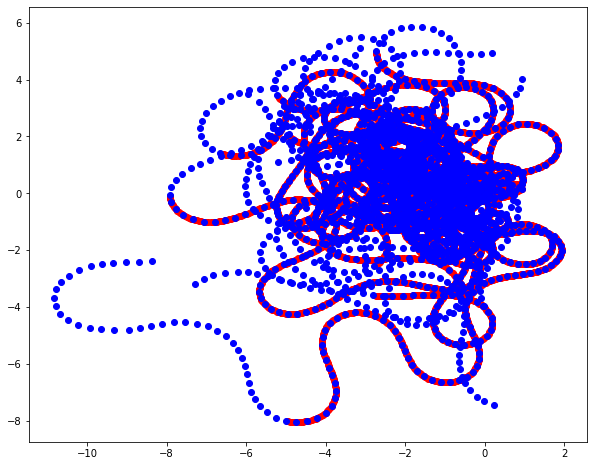

In [8]:
plt.plot(Y_train[:, 0], Y_train[:, 1], 'ro')
plt.plot(Y_eval[:, 0], Y_eval[:, 1], 'bo')
plt.show()

In [9]:
# TENSOR CONVERSION:
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_eval = torch.tensor(X_eval, dtype=torch.float32).to(device)
Y_eval = torch.tensor(Y_eval, dtype=torch.float32).to(device)


In [43]:
t_max, t_min = torch.tensor([T_max], device=device), torch.tensor([0.0], device=device)
x_max, x_min = Y_eval.max(dim=0)[0][0], Y_eval.min(dim=0)[0][0]
y_max, y_min = Y_eval.max(dim=0)[0][1], Y_eval.min(dim=0)[0][1]
theta_max, theta_min = Y_eval.max(dim=0)[0][2], Y_eval.min(dim=0)[0][2]
v_max, v_min = torch.tensor([V_max], device=device), torch.tensor([V_min], device=device)
w_max, w_min = torch.tensor([W_max], device=device), torch.tensor([W_min], device=device)

In [46]:
pinn_c = nn.Sequential(
    nn.Linear(6, 32),
    nn.Tanh(),
    nn.Linear(32, 64),
    nn.Tanh(),
    nn.Linear(64, 32), 
    nn.Tanh(),
    nn.Linear(32, 3)
).to(device)

pinn_c_opti = torch.optim.Adam(
    pinn_c.parameters(), lr=1e-4
    )
loss_mse = nn.MSELoss()
epoch_counter = 0

log_loss_tot = []
log_loss_imit = []
log_loss_f = []
log_loss_boundary = []
        

In [55]:
#pinn_c.load_state_dict(torch.load('pinn_c_240k.pth'))

In [116]:
for i in range(200_000):

    epoch_counter += 1
    pinn_c_opti.zero_grad()
    idx = np.random.randint(0, X_train.shape[0], len(X_train))
    pred = pinn_c(X_train[idx])

    # loss by imit datapoint
    loss_imit = loss_mse(pred, Y_train[idx])

    # loss by pinn
    N_sample = len(X_train)
    
    # random time in range(0, 0.01)
    sampled_t = torch.rand(N_sample, 1).to(device) * (t_max - t_min) + t_min
    
    # random sample
    sampled_x = torch.rand(N_sample, 1).to(device) * (x_max - x_min) + x_min
    sampled_y = torch.rand(N_sample, 1).to(device) * (y_max - y_min) + y_min
    sampled_theta = torch.rand(N_sample, 1).to(device) * (theta_max - theta_min) + theta_min

    # random input
    sampled_u = torch.rand(N_sample, 1).to(device) * (v_max - v_min) + v_min
    sampled_w = torch.rand(N_sample, 1).to(device) * (w_max - w_min) + w_min

    # concat the random componet
    sample = torch.concatenate([
        sampled_x, sampled_y, sampled_theta, 
        sampled_u, sampled_w, 
        sampled_t
    ], -1).to(device)
    sample.requires_grad = True

    # physical system prediction

    pred_output = pinn_c(sample)
    # calc jacobian respect the output of the net
    d_output = vmap(jacrev(pinn_c))(sample).squeeze()
    # extract derivative respect time --> dx_dt, dy_dt, dtheta_dt
    d_output = d_output[:, :, -1]


    # compute the ode of the kin model
    pred_dx = torch.cos(pred_output[:, 2]) * sampled_u.T
    pred_dy = torch.sin(pred_output[:, 2]) * sampled_u.T
    pred_dtheta = sampled_w.T

    physics_val = torch.vstack([pred_dx, pred_dy, pred_dtheta]).T

    # compute the cost 
    F_cost = torch.mean(torch.mean((physics_val - d_output)**2, axis=1))
    F_cost = F_cost

    # boundary condition: No input AKA no velocity
    # --------------------------------------------------------------
    # no velocity ---> no motion:
    # opt 1: apply this at gradient level: calc gradient and put it to 0
    # super crash on the prediction --> do not work 

    # opt 2 : apply this at prediciton level:
    # given x --> f(x) = x (no motion)
    # random time in range(0, 0.01)
    sampled_t = torch.rand(N_sample, 1).to(device) * (t_max - t_min) + t_min
    
    # random sample
    sampled_x = torch.rand(N_sample, 1).to(device) * (x_max - x_min) + x_min
    sampled_y = torch.rand(N_sample, 1).to(device) * (y_max - y_min) + y_min
    sampled_theta = torch.rand(N_sample, 1).to(device) * (theta_max - theta_min) + theta_min

    # random input
    sampled_u = torch.zeros(N_sample, 1).to(device)
    sampled_w = torch.zeros(N_sample, 1).to(device)
    
    # concat the random componet
    sample = torch.concatenate([
        sampled_x, sampled_y, sampled_theta, 
        sampled_u, sampled_w, 
        sampled_t
    ], -1).to(device)
    sample.requires_grad = True

    label_for_boundary = torch.hstack([sampled_x, sampled_y, sampled_theta])

    pred_for_boundary = pinn_c(sample)
    boundary_cost = loss_mse(pred_for_boundary, label_for_boundary)


    loss_imit = 0.1 * loss_imit
    F_cost = 1 * F_cost
    boundary_cost = 0.01 * boundary_cost
    loss = loss_imit + F_cost + boundary_cost
    

    loss.backward()
    pinn_c_opti.step()

    if i % 100 == 0:
        log_loss_tot.append(loss.item())
        log_loss_imit.append(loss_imit.item())
        log_loss_f.append(F_cost.item())
        log_loss_boundary.append(boundary_cost.item())
        
        print(f'iter: {epoch_counter} Loss: {loss.item()}, loss_imit: {loss_imit.item()}, F_cost: {F_cost.item()}, boundary_cost: {boundary_cost.item()}')
        

iter: 314021 Loss: 0.0007624125573784113, loss_imit: 0.0002737639588303864, F_cost: 0.0004603262641467154, boundary_cost: 2.8322319849394262e-05
iter: 314121 Loss: 0.0008021242683753371, loss_imit: 0.0002655883727129549, F_cost: 0.0005073877400718629, boundary_cost: 2.914816104748752e-05
iter: 314221 Loss: 0.0007478347979485989, loss_imit: 0.0002751204592641443, F_cost: 0.0004432403657119721, boundary_cost: 2.9473967515514232e-05
iter: 314321 Loss: 0.0007385398494079709, loss_imit: 0.0002592148375697434, F_cost: 0.00045034257345832884, boundary_cost: 2.898240927606821e-05
iter: 314421 Loss: 0.0007650990737602115, loss_imit: 0.0002698191092349589, F_cost: 0.0004650843911804259, boundary_cost: 3.0195586077752523e-05
iter: 314521 Loss: 0.0007833393756300211, loss_imit: 0.00027166467043571174, F_cost: 0.0004820129834115505, boundary_cost: 2.96617054118542e-05
iter: 314621 Loss: 0.0007478327606804669, loss_imit: 0.0002743076765909791, F_cost: 0.00044437331962399185, boundary_cost: 2.9151746

KeyboardInterrupt: 

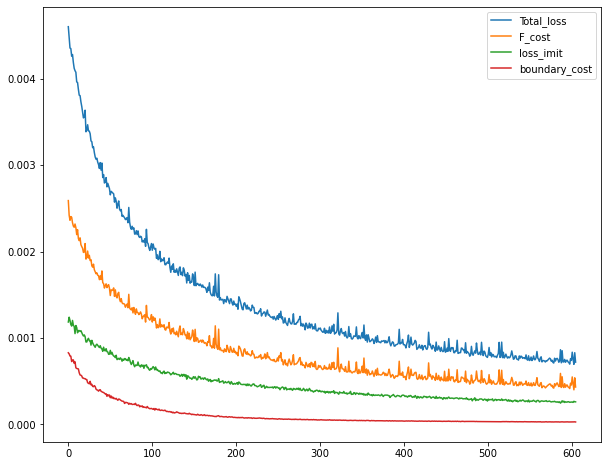

In [118]:
skipp_first = 400
plt.plot(log_loss_tot[skipp_first::5], label='Total_loss')
plt.plot(log_loss_f[skipp_first::5], label='F_cost')
plt.plot(log_loss_imit[skipp_first::5], label='loss_imit')
plt.plot(log_loss_boundary[skipp_first::5], label='boundary_cost')
plt.legend()

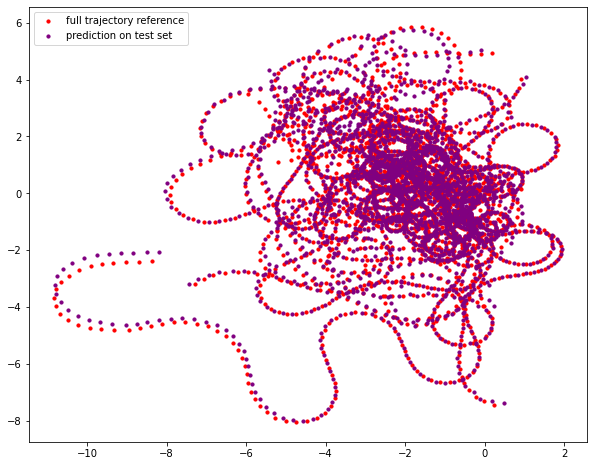

In [119]:
pred_full_traj = pinn_c(X_eval[:].T).detach().cpu().numpy().T
pred = pinn_c(X_train[:]).detach().cpu().numpy().T
plt.scatter(Y_eval.detach().cpu().numpy()[:, 0], Y_eval.detach().cpu().numpy()[:, 1],  c='r', s=10, label='full trajectory reference')
#plt.scatter(pred[0], pred[1], label='prediction on train set')
plt.scatter(pred_full_traj[0], pred_full_traj[1], label='prediction on test set', s=10, c='purple')

plt.legend()


In [100]:
torch.save(pinn_c.state_dict(), 'pinn_c_BigDataset_201500k.pth')

In [36]:
pinn_c.load_state_dict(torch.load('pinn_c_240k.pth'))

<All keys matched successfully>

In [64]:
import sys
sys.path.append('..')
import simple_neural_mpc.utils.trajectory as traj_generator

In [66]:
circle = traj_generator.Circle()
t = np.linspace(0, 2*np.pi, 100)

pos_log = []
vel_log = []
acc_log = []

for time_delta in t:
    x_ref, y_ref = circle.update(time_delta)['p']
    psi_ref = circle.update(time_delta)['psi']

    dx_ref, dy_ref = circle.update(time_delta)['pd']
    dpsi_ref = circle.update(time_delta)['psid']

    ddx_ref, ddy_ref = circle.update(time_delta)['pdd']

    state_ref = np.array([x_ref, y_ref, psi_ref])
    vel_ref = np.array([dx_ref, dy_ref, dpsi_ref])
    acc_ref = np.array([ddx_ref, ddy_ref, 0])
    
    pos_log.append(state_ref)   
    vel_log.append(vel_ref)
    acc_log.append(acc_ref)


In [81]:
traj_ref_pose = np.vstack(pos_log)
traj_ref_vel = np.vstack(vel_log)
traj_ref_acc = np.vstack(acc_log)

traj_ref_tensor = torch.tensor(traj_ref_pose, dtype=torch.float32, device=device)
traj_ref_vel_tensor = torch.tensor(traj_ref_vel, dtype=torch.float32, device=device)
traj_ref_acc_tensor = torch.tensor(traj_ref_acc, dtype=torch.float32, device=device)

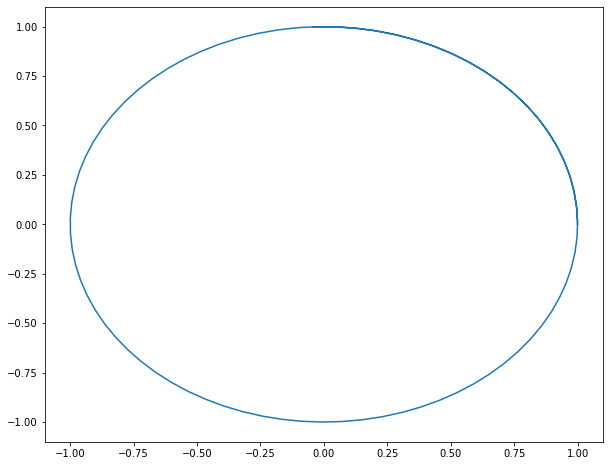

In [68]:
plt.plot(traj_ref_pose[:, 0], traj_ref_pose[:, 1], label='reference trajectory')

In [75]:
X_0 = traj_ref_tensor[0].to(device)
action = torch.Tensor([0, 0]).to(device)
T_net = torch.Tensor([0.1]).to(device)

In [76]:
input_tensor = torch.hstack([X_0, action, T_net])
x_net = pinn_c(input_tensor)

In [77]:
def v_des(dot_x, dot_y): return torch.sqrt(dot_x**2 + dot_y**2)

def w_des(dot_x, dot_y, ddot_x, ddot_y):
    return (ddot_y * dot_x - ddot_x * dot_y) / (dot_x**2 + dot_y**2)

In [78]:
delta_t = t[1] - t[0]

In [120]:
X_0 = torch.tensor([0,0,0], dtype=torch.float32).to(device)
action = torch.tensor([0, 0], dtype=torch.float32).to(device)
T_net = torch.FloatTensor([0.1]).to(device)   

input_tensor = torch.hstack([X_0, action, T_net])
traj_gen = [] 
traj_gen_pin = []

control_input = (X_0 - traj_ref_tensor[0])
x, y, theta = X_0
for iter in range(99):
        
    with torch.no_grad():
        x_net_pin = pinn_c(input_tensor)    
        
        x += action[0] * torch.cos(x_net[2]) * delta_t
        y += action[0] * torch.sin(x_net[2]) * delta_t
        theta += action[1] * delta_t


        v = v_des(*traj_ref_vel_tensor[iter, :2])
        w = w_des(*traj_ref_vel_tensor[iter, :2], *traj_ref_acc_tensor[iter, :2])
        
        

        action = torch.stack([v, w])
        x_net = torch.hstack([x, y, theta])

        input_tensor = torch.hstack([x_net, action, T_net])
        traj_gen.append(x_net.cpu().detach().numpy())
        traj_gen_pin.append(x_net_pin.cpu().detach().numpy())

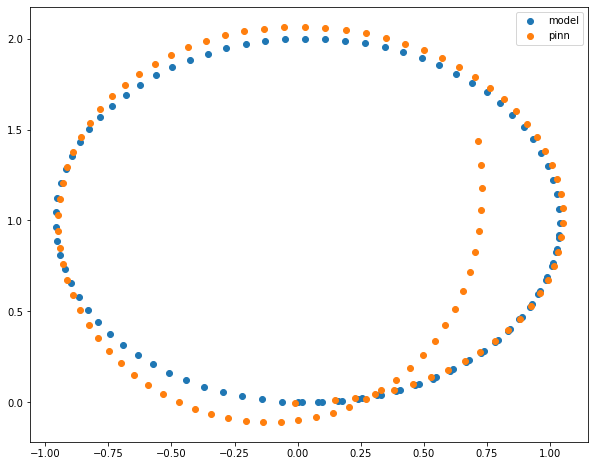

In [122]:
plt.scatter(np.stack(traj_gen)[:,0], np.stack(traj_gen)[:, 1], label='model')
plt.scatter(np.stack(traj_gen_pin)[:,0], np.stack(traj_gen_pin)[:, 1], label='pinn')
plt.legend()